In [248]:
#part a
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import seaborn as sns

In [249]:
adult_df = pd.read_csv('../csv_files/adult.csv')

adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [250]:
#Complete One-hot encoding for all 9 'object' attributes
#targeet value is income - begin with that 

adult_df['has_high_income'] = adult_df['income'].apply(lambda x: True if x == ">50K" else False)
adult_df.drop('income', axis=1, inplace=True)
adult_df['has_high_income'] = adult_df['has_high_income'].astype(int)



In [251]:
#1 hot encoding for workclass
print(adult_df['workclass'].unique())

['Private' 'Local-gov' '?' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']


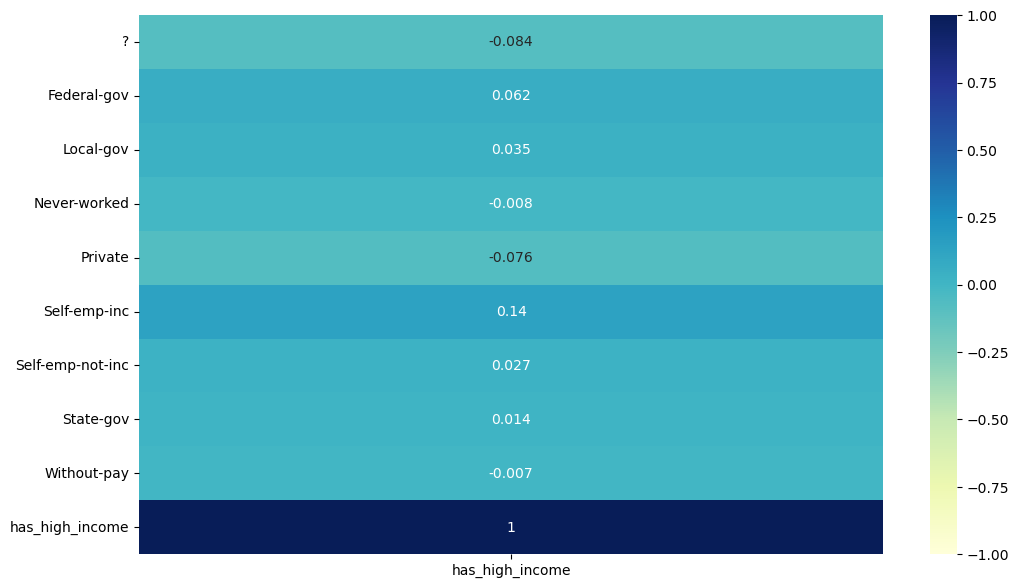

In [252]:
workclass_df = pd.get_dummies(adult_df['workclass'])

workclass_df = workclass_df.astype(int)

workclass_df= pd.concat([workclass_df, adult_df[['has_high_income']]], axis=1)

corr_matrix = workclass_df.corr()
plt.figure(figsize=(12, 7))
workclass_df_matrix = corr_matrix[['has_high_income']]
sns.heatmap(workclass_df_matrix, annot=True, cmap="YlGnBu", vmin=-1, vmax=1)

plt.show()

In [253]:
#combine attributtes with similar values
workclass_df['workclass_w/o_pay/never_worked'] = np.any(workclass_df[['Without-pay', 'Never-worked']], axis=1).astype(int)
workclass_df['workclass_private/?'] = np.any(workclass_df[['?', 'Private']], axis=1).astype(int)
workclass_df['workclass_local_gov/self-emp'] = np.any(workclass_df[['Local-gov', 'Self-emp-inc']], axis=1).astype(int)
workclass_df['workclass_local_gov/self-emp-not-inc'] = np.any(workclass_df[['Local-gov', 'Self-emp-not-inc']], axis=1).astype(int)

workclass_df.drop(columns=['Without-pay', 'Never-worked', '?', 'Private', 'Local-gov', 'Self-emp-inc', 'Local-gov', 'Self-emp-not-inc'], inplace=True)
adult_df.drop(columns=['workclass', 'has_high_income'], inplace=True)
adult_df = pd.concat([adult_df, workclass_df], axis=1)

#one-hot encoding done for workclass feature

In [254]:
#begin 1 hot encoding for education feature

print(adult_df['education'].unique())

adult_df.info()

['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   age                                   48842 non-null  int64 
 1   fnlwgt                                48842 non-null  int64 
 2   education                             48842 non-null  object
 3   educational-num                       48842 non-null  int64 
 4   marital-status                        48842 non-null  object
 5   occupation                            48842 non-null  object
 6   relationship                          48842 non-null  object
 7   race                                  48842 non-null  object
 8   gender                                48842 non-null  o

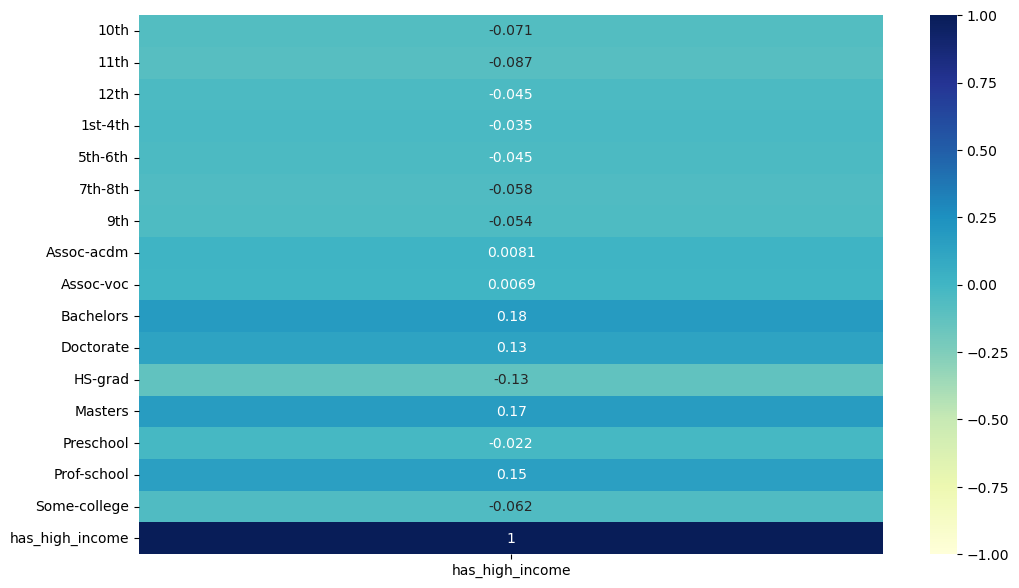

In [255]:
education_df = pd.get_dummies(adult_df['education'])

education_df = education_df.astype(int)

education_df= pd.concat([education_df, adult_df[['has_high_income']]], axis=1)

corr_matrix = education_df.corr()
plt.figure(figsize=(12, 7))
education_df_matrix = corr_matrix[['has_high_income']]
sns.heatmap(education_df_matrix, annot=True, cmap="YlGnBu", vmin=-1, vmax=1)

plt.show()



In [256]:
education_df['education_elementary'] = np.any(education_df[['1st-4th','Preschool']], axis=1).astype(int)
education_df['education_middle_school'] = np.any(education_df[['5th-6th','7th-8th','Some-college']], axis=1).astype(int)
education_df['education_high_school'] = np.any(education_df[['9th','10th','11th','12th']], axis=1).astype(int)
education_df['education_associate'] = np.any(education_df[['Assoc-acdm','Assoc-voc']], axis=1).astype(int)
education_df['education_college_education'] = np.any(education_df[['Bachelors','Masters', 'Prof-school']], axis=1).astype(int)

education_df.rename(columns={'HS-grad': 'education_hs_grad'}, inplace=True)

education_df = education_df.drop(columns=['1st-4th', 'Preschool', '5th-6th', '7th-8th', 'Some-college',
                                           '9th', '10th', '11th', '12th', 'Assoc-acdm', 'Assoc-voc',
                                           'Bachelors', 'Masters', 'Doctorate', 'Prof-school', 'has_high_income'])

hs_grad = education_df.pop('education_hs_grad')
education_df.insert(3, 'education_hs_grad', hs_grad)

adult_df = pd.concat([adult_df, education_df], axis=1)

adult_df.drop(columns=['education', 'educational-num'], inplace=True, axis=1) #drop original education feature and its numerical representation

adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   age                                   48842 non-null  int64 
 1   fnlwgt                                48842 non-null  int64 
 2   marital-status                        48842 non-null  object
 3   occupation                            48842 non-null  object
 4   relationship                          48842 non-null  object
 5   race                                  48842 non-null  object
 6   gender                                48842 non-null  object
 7   capital-gain                          48842 non-null  int64 
 8   capital-loss                          48842 non-null  int64 
 9   hours-per-week                        48842 non-null  int64 
 10  native-country                        48842 non-null  object
 11  Federal-gov                 

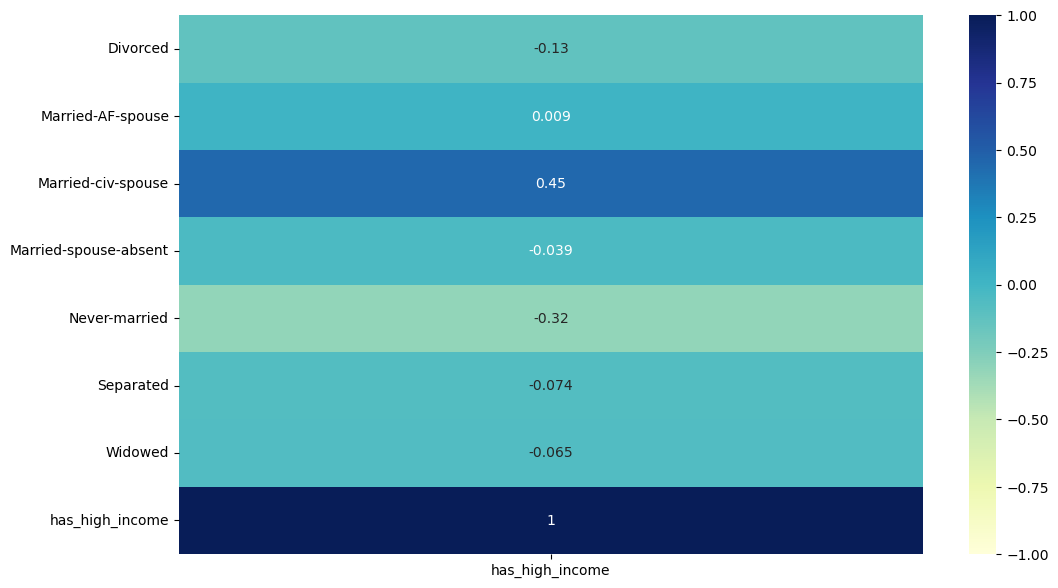

In [257]:
marriage_df = pd.get_dummies(adult_df['marital-status'])
marriage_df = marriage_df.astype(int)

marriage_df['has_high_income'] = adult_df['has_high_income']
corr_matrix = marriage_df.corr()
plt.figure(figsize=(12, 7))
marriage_df_matrix = corr_matrix[['has_high_income']]
sns.heatmap(marriage_df_matrix, annot=True, cmap="YlGnBu", vmin=-1, vmax=1)

plt.show()


In [258]:
marriage_df['marriage_separated/widowed'] = np.any(marriage_df[['Widowed','Separated']], axis=1).astype(int)
marriage_df['marriage_absent-spouse/never-married'] = np.any(marriage_df[['Married-spouse-absent','Never-married']], axis=1).astype(int)

marriage_df.drop(columns=['Married-AF-spouse', 'Widowed', 'Separated', 'Married-spouse-absent', 'Never-married', 'has_high_income'], inplace=True)

marriage_df.rename(columns={'Married-civ-spouse': 'marriage_civ_spouse', 'Divorced' : 'marriage_divorce'}, inplace=True)

adult_df = pd.concat([adult_df, marriage_df], axis=1)

adult_df.drop(columns=['marital-status'], inplace=True)
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   age                                   48842 non-null  int64 
 1   fnlwgt                                48842 non-null  int64 
 2   occupation                            48842 non-null  object
 3   relationship                          48842 non-null  object
 4   race                                  48842 non-null  object
 5   gender                                48842 non-null  object
 6   capital-gain                          48842 non-null  int64 
 7   capital-loss                          48842 non-null  int64 
 8   hours-per-week                        48842 non-null  int64 
 9   native-country                        48842 non-null  object
 10  Federal-gov                           48842 non-null  int64 
 11  State-gov                   

In [259]:
gender_df = pd.get_dummies(adult_df['gender'], drop_first=True).astype(int)
adult_df = pd.concat([adult_df, gender_df], axis=1)
adult_df = adult_df.drop(columns=['gender'])

adult_df.rename(columns={'Male': 'is_Male'}, inplace=True)
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   age                                   48842 non-null  int64 
 1   fnlwgt                                48842 non-null  int64 
 2   occupation                            48842 non-null  object
 3   relationship                          48842 non-null  object
 4   race                                  48842 non-null  object
 5   capital-gain                          48842 non-null  int64 
 6   capital-loss                          48842 non-null  int64 
 7   hours-per-week                        48842 non-null  int64 
 8   native-country                        48842 non-null  object
 9   Federal-gov                           48842 non-null  int64 
 10  State-gov                             48842 non-null  int64 
 11  has_high_income             

In [260]:
print(adult_df['race'].unique())

['Black' 'White' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']


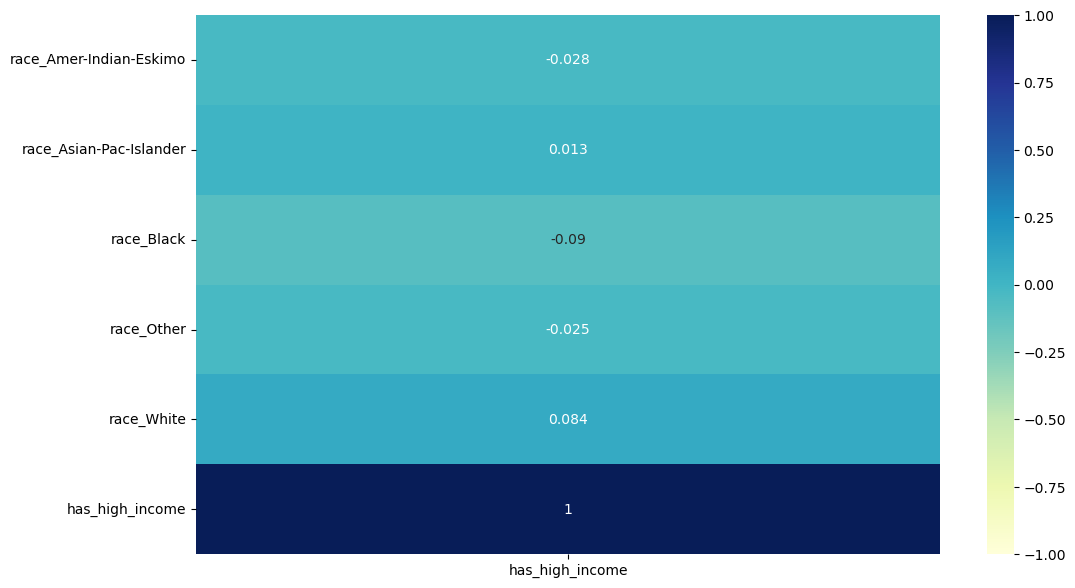

In [261]:
race_df = pd.get_dummies(adult_df['race'], prefix='race')
race_df = race_df.astype(int)

race_df['has_high_income'] = adult_df['has_high_income']
corr_matrix = race_df.corr()
plt.figure(figsize=(12, 7))
race_df_matrix = corr_matrix[['has_high_income']]
sns.heatmap(race_df_matrix, annot=True, cmap="YlGnBu", vmin=-1, vmax=1)

plt.show()


In [262]:
race_df['race_other'] = np.any(race_df[['race_Other','race_Amer-Indian-Eskimo']], axis=1).astype(int)
race_df = race_df.drop(columns=['has_high_income', 'race_Other', 'race_Amer-Indian-Eskimo'])

adult_df = pd.concat([adult_df, race_df], axis=1)
adult_df = adult_df.drop(columns=['race'])
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 30 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   age                                   48842 non-null  int64 
 1   fnlwgt                                48842 non-null  int64 
 2   occupation                            48842 non-null  object
 3   relationship                          48842 non-null  object
 4   capital-gain                          48842 non-null  int64 
 5   capital-loss                          48842 non-null  int64 
 6   hours-per-week                        48842 non-null  int64 
 7   native-country                        48842 non-null  object
 8   Federal-gov                           48842 non-null  int64 
 9   State-gov                             48842 non-null  int64 
 10  has_high_income                       48842 non-null  int64 
 11  workclass_w/o_pay/never_work

In [263]:
print(adult_df['occupation'].unique())

['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' '?'
 'Other-service' 'Prof-specialty' 'Craft-repair' 'Adm-clerical'
 'Exec-managerial' 'Tech-support' 'Sales' 'Priv-house-serv'
 'Transport-moving' 'Handlers-cleaners' 'Armed-Forces']


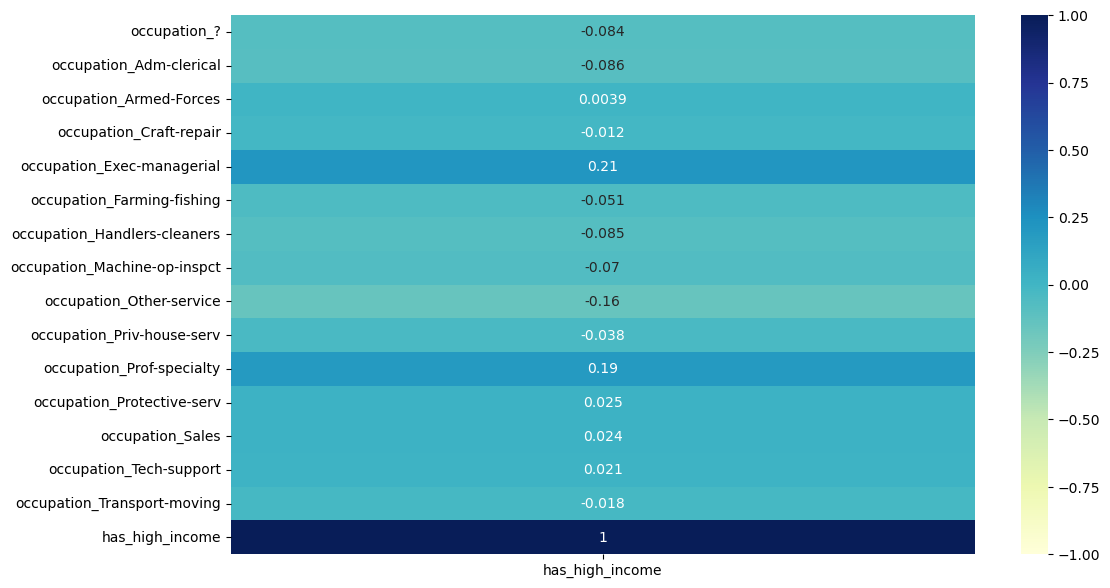

In [264]:
occupation_df = pd.get_dummies(adult_df['occupation'], prefix='occupation')
occupation_df = occupation_df.astype(int)

occupation_df['has_high_income'] = adult_df['has_high_income']
corr_matrix = occupation_df.corr()
plt.figure(figsize=(12, 7))
occupation_df_matrix = corr_matrix[['has_high_income']]
sns.heatmap(occupation_df_matrix, annot=True, cmap="YlGnBu", vmin=-1, vmax=1)

plt.show()

In [265]:

occupation_df['occupation_professionals'] = np.any(occupation_df[['occupation_Prof-specialty', 'occupation_Exec-managerial']], axis=1).astype(int)
occupation_df['occupation_sales/support/security'] = np.any(occupation_df[['occupation_Sales', 'occupation_Tech-support', 'occupation_Protective-serv']], axis=1).astype(int)
occupation_df['occupation_repair/transportation'] = np.any(occupation_df[['occupation_Transport-moving', 'occupation_Craft-repair']], axis=1).astype(int)
occupation_df['occupation_low_skill'] = np.any(occupation_df[['occupation_?', 'occupation_Adm-clerical', 'occupation_Farming-fishing', 
                                                              'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Priv-house-serv']], axis=1).astype(int)


occupation_df.drop(columns=['occupation_Prof-specialty', 'occupation_Exec-managerial', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Protective-serv',
                            'occupation_Transport-moving', 'occupation_Craft-repair', 'occupation_?', 'occupation_Adm-clerical', 'occupation_Farming-fishing',
                            'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Priv-house-serv', 'has_high_income'], inplace=True)


adult_df.drop(columns='occupation', inplace=True)
adult_df = pd.concat([adult_df, occupation_df], axis=1)
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 35 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   age                                   48842 non-null  int64 
 1   fnlwgt                                48842 non-null  int64 
 2   relationship                          48842 non-null  object
 3   capital-gain                          48842 non-null  int64 
 4   capital-loss                          48842 non-null  int64 
 5   hours-per-week                        48842 non-null  int64 
 6   native-country                        48842 non-null  object
 7   Federal-gov                           48842 non-null  int64 
 8   State-gov                             48842 non-null  int64 
 9   has_high_income                       48842 non-null  int64 
 10  workclass_w/o_pay/never_worked        48842 non-null  int64 
 11  workclass_private/?         

In [266]:
#Investigate relationship

print(adult_df['relationship'].unique())

['Own-child' 'Husband' 'Not-in-family' 'Unmarried' 'Wife' 'Other-relative']


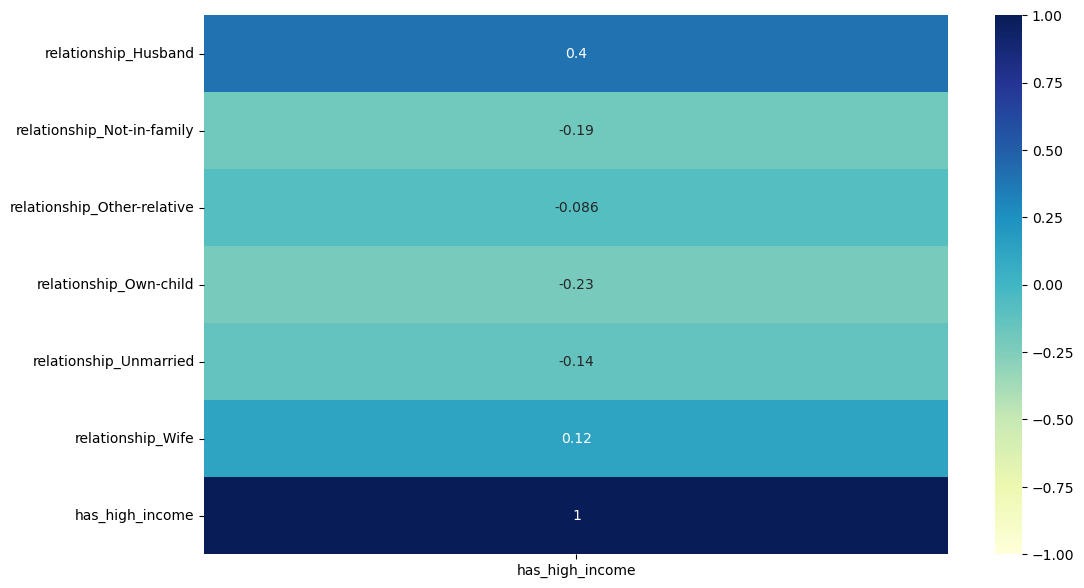

In [267]:
relationship_df = pd.get_dummies(adult_df['relationship'], prefix='relationship')
relationship_df = relationship_df.astype(int)

relationship_df['has_high_income'] = adult_df['has_high_income']
corr_matrix = relationship_df.corr()
plt.figure(figsize=(12, 7))
relationship_df_matrix = corr_matrix[['has_high_income']]
sns.heatmap(relationship_df_matrix, annot=True, cmap="YlGnBu", vmin=-1, vmax=1)

plt.show()

In [268]:
relationship_df.drop(columns='has_high_income', inplace=True)
adult_df.drop(columns='relationship', inplace=True)
adult_df = pd.concat([adult_df, relationship_df], axis=1)
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 40 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   age                                   48842 non-null  int64 
 1   fnlwgt                                48842 non-null  int64 
 2   capital-gain                          48842 non-null  int64 
 3   capital-loss                          48842 non-null  int64 
 4   hours-per-week                        48842 non-null  int64 
 5   native-country                        48842 non-null  object
 6   Federal-gov                           48842 non-null  int64 
 7   State-gov                             48842 non-null  int64 
 8   has_high_income                       48842 non-null  int64 
 9   workclass_w/o_pay/never_worked        48842 non-null  int64 
 10  workclass_private/?                   48842 non-null  int64 
 11  workclass_local_gov/self-emp

In [269]:
print(adult_df['native-country'].unique())

['United-States' '?' 'Peru' 'Guatemala' 'Mexico' 'Dominican-Republic'
 'Ireland' 'Germany' 'Philippines' 'Thailand' 'Haiti' 'El-Salvador'
 'Puerto-Rico' 'Vietnam' 'South' 'Columbia' 'Japan' 'India' 'Cambodia'
 'Poland' 'Laos' 'England' 'Cuba' 'Taiwan' 'Italy' 'Canada' 'Portugal'
 'China' 'Nicaragua' 'Honduras' 'Iran' 'Scotland' 'Jamaica' 'Ecuador'
 'Yugoslavia' 'Hungary' 'Hong' 'Greece' 'Trinadad&Tobago'
 'Outlying-US(Guam-USVI-etc)' 'France' 'Holand-Netherlands']


<Axes: >

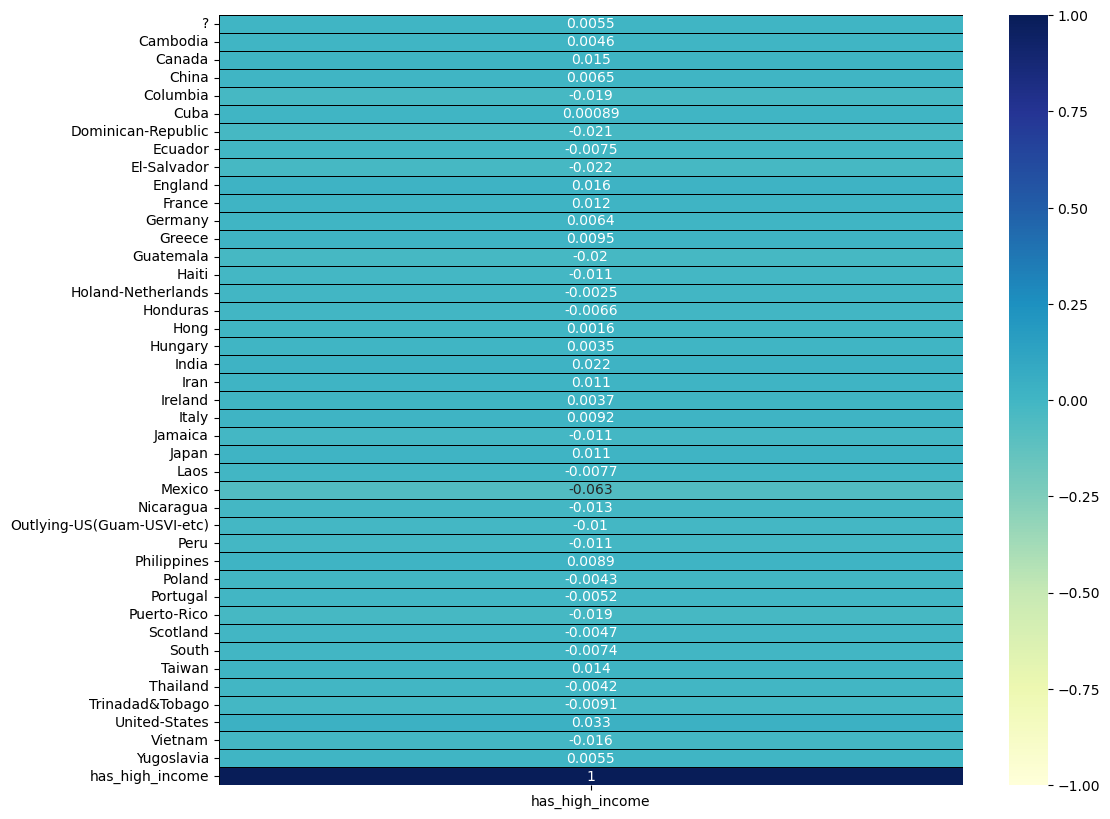

In [270]:
country_df = pd.get_dummies(adult_df['native-country'])
country_df['has_high_income'] = adult_df['has_high_income']

corr_matrix = country_df.corr()
plt.figure(figsize=(12, 10))
country_df_matrix = corr_matrix[['has_high_income']]
sns.heatmap(country_df_matrix, annot=True, cmap="YlGnBu", vmin=-1, vmax=1, linewidths=0.5, linecolor='black')

In [271]:
#Aggregate countries by Continent

continent_df = pd.DataFrame()

continent_df['continent_North_America'] = np.any(country_df[['United-States','Canada']], axis=1).astype(int)

continent_df['continent_Central_America'] = np.any(country_df[['Mexico', 'Puerto-Rico', 'Cuba', 'Dominican-Republic', 'Jamaica', 'Honduras', 
                                                     'Guatemala', 'El-Salvador', 'Nicaragua', 'Trinadad&Tobago', 'Haiti']], axis=1).astype(int)

continent_df['continent_South_America'] = np.any(country_df[['Peru', 'Columbia', 'Ecuador']], axis=1).astype(int)

continent_df['continent_Europe'] = np.any(country_df[['Ireland', 'Germany', 'Portugal', 'Italy', 'Scotland', 'Hungary', 'France', 'Greece', 
                                            'Holand-Netherlands', 'England', 'Poland', 'Yugoslavia']], axis=1).astype(int)

continent_df['continent_Asia'] = np.any(country_df[['Philippines', 'Thailand', 'Vietnam', 'India', 'Cambodia', 'China', 'Taiwan', 'Iran', 'Japan', 'Hong', 'Laos']], axis=1).astype(int)

continent_df['continent_Others'] = np.any(country_df[['?', 'Outlying-US(Guam-USVI-etc)', 'South']], axis=1).astype(int)

continent_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   continent_North_America    48842 non-null  int64
 1   continent_Central_America  48842 non-null  int64
 2   continent_South_America    48842 non-null  int64
 3   continent_Europe           48842 non-null  int64
 4   continent_Asia             48842 non-null  int64
 5   continent_Others           48842 non-null  int64
dtypes: int64(6)
memory usage: 2.2 MB


In [272]:
adult_df.info()
adult_df.drop(columns='native-country', inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 40 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   age                                   48842 non-null  int64 
 1   fnlwgt                                48842 non-null  int64 
 2   capital-gain                          48842 non-null  int64 
 3   capital-loss                          48842 non-null  int64 
 4   hours-per-week                        48842 non-null  int64 
 5   native-country                        48842 non-null  object
 6   Federal-gov                           48842 non-null  int64 
 7   State-gov                             48842 non-null  int64 
 8   has_high_income                       48842 non-null  int64 
 9   workclass_w/o_pay/never_worked        48842 non-null  int64 
 10  workclass_private/?                   48842 non-null  int64 
 11  workclass_local_gov/self-emp

<Axes: >

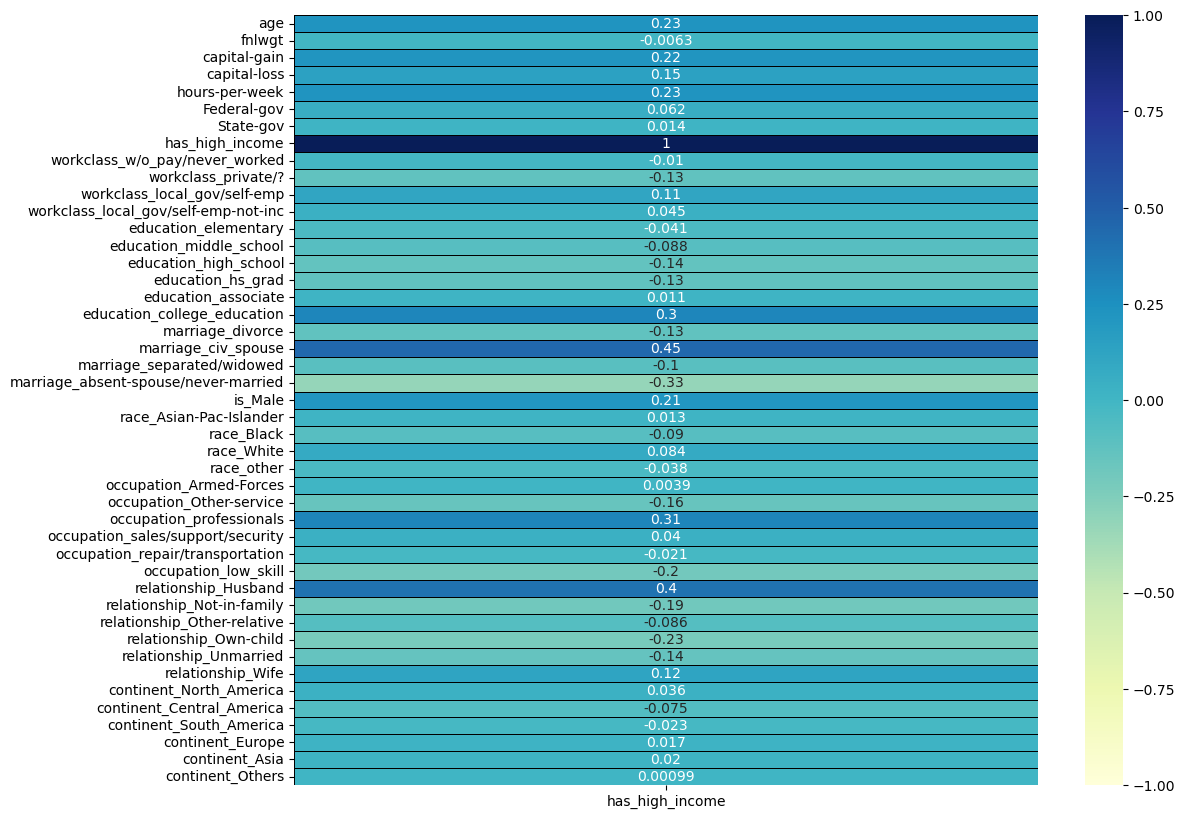

In [273]:
#All data has been turned into numerical values -inspect non-binary attributes

#Visualize data correlation with respect to income
adult_df = pd.concat([adult_df, continent_df], axis=1)

corr_matrix = adult_df.corr()
plt.figure(figsize=(12, 10))
adult_df_matrix = corr_matrix[['has_high_income']]
sns.heatmap(adult_df_matrix, annot=True, cmap="YlGnBu", vmin=-1, vmax=1, linewidths=0.5, linecolor='black')

In [274]:
#part b

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE

X = adult_df.drop(columns=['has_high_income'])
y = adult_df['has_high_income']

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=1, train_size=0.8)

model = LogisticRegression(random_state=1)

# Use RFE to select the top 5 features - code retrieved on Oct-15-2024 from:
# https://medium.com/@rithpansanga/logistic-regression-for-feature-selection-selecting-the-right-features-for-your-model-410ca093c5e0

rfe = RFE(model, n_features_to_select=5)  
rfe.fit(X_train, y_train)

model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

LogisticRegression(random_state=1)

In [275]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_proba)

In [276]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [277]:
score = model.score(X_test,y_test)

print("auc: %.2f" % auc)
print("model score: %.2f" % score)

print(classification_report(y_test,y_pred))

auc: 0.61
model score: 0.80
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      7387
           1       0.73      0.28      0.40      2382

    accuracy                           0.80      9769
   macro avg       0.77      0.62      0.64      9769
weighted avg       0.79      0.80      0.76      9769



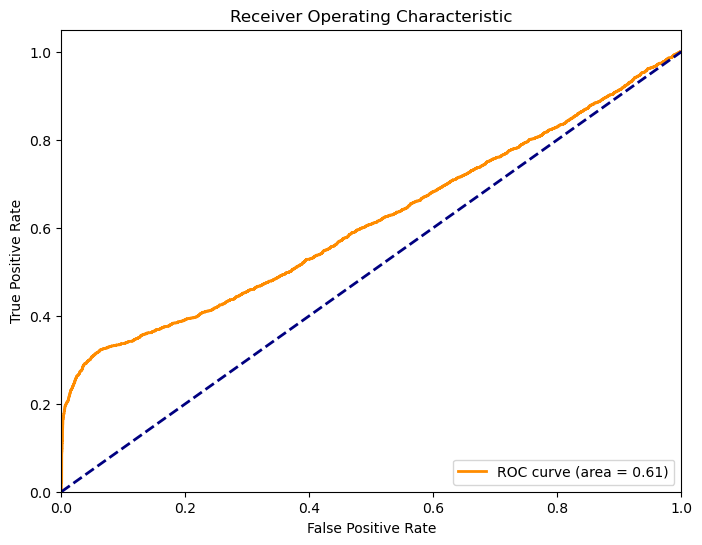

In [278]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [279]:
#These attriburtes provide poor ROC score - and a very poor 'recall' score
#Add high negative correlation values to better predict 'recall'

print(X_train.columns[rfe.support_])

Index(['education_elementary', 'education_high_school', 'marriage_civ_spouse',
       'occupation_professionals', 'relationship_Own-child'],
      dtype='object')


In [280]:
#These attriburtes provide poor ROC score - and a very poor 'recall' score
#Add high negative correlation values to better predict 'recall'

#get the negatively correlated features (from the previous corr_matrix)
negative_corr_features = adult_df[['marriage_absent-spouse/never-married', 'relationship_Not-in-family', 'relationship_Own-child', 
                                   'relationship_Unmarried', 'occupation_Other-service']]

positive_corr_features = adult_df[['education_elementary', 'education_high_school', 'marriage_civ_spouse',
                                   'occupation_professionals']] #get the previously selected features


X_2 = pd.concat([negative_corr_features, positive_corr_features], axis=1)

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2,y,random_state=2, train_size=0.8)


In [281]:
model.fit(X_train_2, y_train_2)

LogisticRegression(random_state=1)

In [282]:
y_proba_2 = model.predict_proba(X_test_2)[:, 1]

y_pred_2 = model.predict(X_test_2)

fpr, tpr, thresholds = roc_curve(y_test_2, y_proba_2)

auc = roc_auc_score(y_test_2, y_proba_2)

print("auc: %.2f" % auc)

print("model score: %.2f" % model.score(X_test_2, y_test_2))

print(classification_report(y_test_2,y_pred_2))



auc: 0.84
model score: 0.81
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      7474
           1       0.69      0.37      0.48      2295

    accuracy                           0.81      9769
   macro avg       0.76      0.66      0.69      9769
weighted avg       0.80      0.81      0.79      9769



In [283]:
# Results: 
#     Significant increase in auc score (0.61 -> 0.84)
#     Increase in all other metrics

In [284]:
# Train L1 Regularization model now

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X, y, random_state=3, train_size=0.8)

model_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=1)
model_l1.fit(X_train, y_train)

y_pred_3 = model_l1.predict(X_test_3)
y_proba_3 = model_l1.predict_proba(X_test_3)[:, 1]

auc_l1 = roc_auc_score(y_test_3, y_proba_3)

print("auc: L1 %.2f" % auc_l1)
print("model score: %.2f" % model_l1.score(X_test_3, y_test_3))

print(classification_report(y_test_3, y_pred_3))

auc: L1 0.90
model score: 0.85
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7446
           1       0.75      0.58      0.65      2323

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769



In [285]:
# Train L2 Regularization model now

X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X, y, random_state=3, train_size=0.8)


model_l2 = LogisticRegression(penalty='l2', random_state=4)
model_l2.fit(X_train_4, y_train_4)

y_pred_l2 = model_l2.predict(X_test_4)
y_proba_l2 = model_l2.predict_proba(X_test_4)[:, 1]


auc_l2 = roc_auc_score(y_test_4, y_proba_l2)

print("auc: L2 %.2f" % auc_l2)
print("model score: %.2f" % model_l2.score(X_test_4, y_test_4))

print(classification_report(y_test_4, y_pred_l2))

auc: L2 0.60
model score: 0.80
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      7446
           1       0.73      0.27      0.39      2323

    accuracy                           0.80      9769
   macro avg       0.77      0.62      0.64      9769
weighted avg       0.79      0.80      0.77      9769



/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [286]:
#Results: 
# L1 model provided significantly higher results over original models and L2

In [287]:
    # - part c 
    # -train a k-fold cross validation with 10 folds
    # - evaluate with metrics (accuracy, precision, recall, F1-score and ROC-AUC)
    # - generate a confusion matrix
    # - generate a heat map

from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.model_selection import StratifiedKFold

In [288]:
#Train a kfold with L1

kf= StratifiedKFold(n_splits=10)

accuracy = cross_val_score(model_l1, X, y.values.ravel(), cv=kf, scoring='accuracy')
precision = cross_val_score(model_l1, X, y.values.ravel(), cv=kf, scoring='precision')
f1 = cross_val_score(model_l1, X, y.values.ravel(), cv=kf, scoring='f1')
roc_auc = cross_val_score(model_l1, X, y.values.ravel(), cv=kf, scoring='roc_auc')
recall = cross_val_score(model_l1, X, y.values.ravel(), cv=kf, scoring='recall')

y_pred = cross_val_predict(model_l1, X, y.values.ravel(), cv=kf)

In [289]:
print("Stratified K-Fold metrics for '1' values with L1 Regression Model: \n")
print("Average accuracy:\n %.2f" % np.average(accuracy), '\n')
print("Average precision:\n %.2f" % np.average(precision), '\n')
print("Average recall:\n %.2f" % np.average(recall), '\n')
print("Average f1:\n %.2f" % np.average(f1), '\n')
print("Average roc_auc:\n %.2f" % np.average(roc_auc))

Stratified K-Fold metrics for '1' values with L1 Regression Model: 

Average accuracy:
 0.85 

Average precision:
 0.73 

Average recall:
 0.59 

Average f1:
 0.65 

Average roc_auc:
 0.90


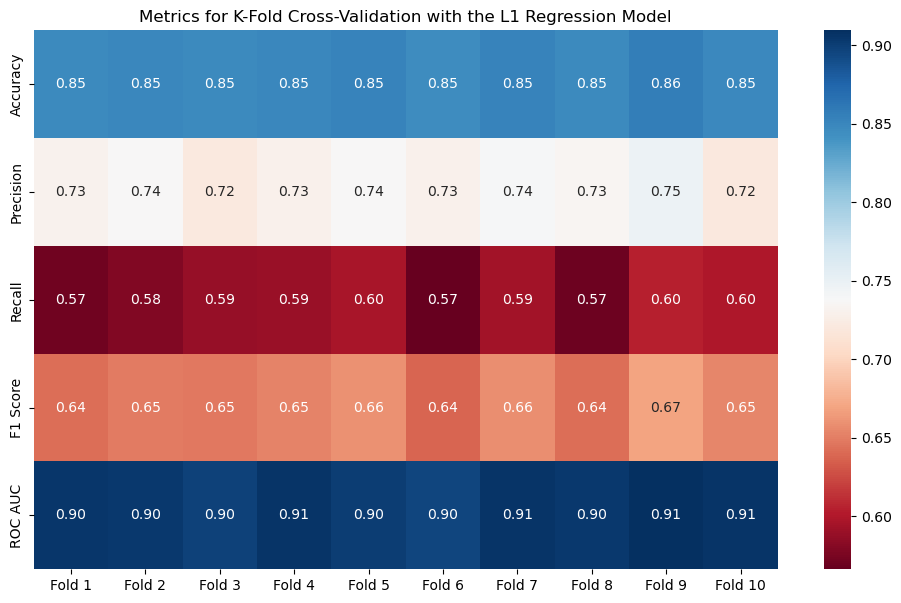

In [290]:
metrics = [accuracy, precision, recall, f1, roc_auc]
plt.figure(figsize=(12, 7))

sns.heatmap(metrics, annot=True, fmt=".2f", cmap='RdBu',
    xticklabels=['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5', 'Fold 6', 'Fold 7', 'Fold 8', 'Fold 9', 'Fold 10'],
    yticklabels=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'])

plt.title('Metrics for K-Fold Cross-Validation with the L1 Regression Model')
plt.show()

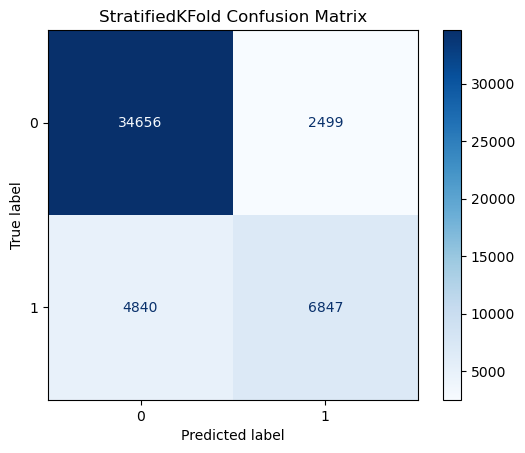

In [291]:
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

cnf_matrix = confusion_matrix(y ,y_pred)

tn, fp, fn, tp = cnf_matrix.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('StratifiedKFold Confusion Matrix')
plt.show()